In [1]:
import pandas as pd

In [2]:
data_path ='/Users/khj/Desktop/Project_ongoing/DRBP/data/raw_data'

DBP = pd.read_csv(f'{data_path}/DBP.csv')
RBP = pd.read_csv(f'{data_path}/RBP.csv')
NDBP = pd.read_csv(f'{data_path}/NDBP.csv')
NRBP = pd.read_csv(f'{data_path}/NRBP.csv')

In [34]:
DBP.iloc[0,0]

'>ENSP00000363822'

In [30]:
DBP[DBP['ID']=='>ENSP00000363745']

,ID,sequence,class


In [19]:
uni_DBP = pd.read_csv(f'./ENSP2uniprotID/DBP_uniprot_mapping.tsv',sep='\t')
uni_RBP = pd.read_csv(f'./ENSP2uniprotID/RBP_uniprot_mapping.tsv',sep='\t')
uni_NDBP = pd.read_csv(f'./ENSP2uniprotID/NDBP_uniprot_mapping.tsv',sep='\t')
uni_NRBP = pd.read_csv(f'./ENSP2uniprotID/NRBP_uniprot_mapping.tsv',sep='\t')

In [21]:
uni_DBP['From'] = '>'+uni_DBP['From'].astype(str)
uni_RBP['From'] = '>'+uni_RBP['From'].astype(str)
uni_NDBP['From'] = '>'+uni_NDBP['From'].astype(str)
uni_NRBP['From'] = '>'+uni_NRBP['From'].astype(str)
uni_NRBP

,From,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length
0,>ENSP00000359396,A6NC42,reviewed,DPPA5_HUMAN,Developmental pluripotency-associated 5 protei...,DPPA5 ESG1,Homo sapiens (Human),116
1,>ENSP00000363745,O43390,reviewed,HNRPR_HUMAN,Heterogeneous nuclear ribonucleoprotein R (hnR...,HNRNPR HNRPR,Homo sapiens (Human),633
2,>ENSP00000368881,O60870,reviewed,KIN17_HUMAN,DNA/RNA-binding protein KIN17 (Binding to curv...,KIN BTCD KIN17,Homo sapiens (Human),393
3,>ENSP00000304139,O75526,reviewed,RMXL2_HUMAN,"RNA-binding motif protein, X-linked-like-2 (Te...",RBMXL2 HNRNPGT,Homo sapiens (Human),392
4,>ENSP00000407724,O75534,reviewed,CSDE1_HUMAN,Cold shock domain-containing protein E1 (N-ras...,CSDE1 D1S155E KIAA0885 NRU UNR,Homo sapiens (Human),798
...,...,...,...,...,...,...,...,...
17442,>ENSP00000358071,Q9Y6Y8,reviewed,S23IP_HUMAN,SEC23-interacting protein (p125),SEC23IP MSTP053,Homo sapiens (Human),1000
17443,>ENSP00000284818,Q9Y6Y9,reviewed,LY96_HUMAN,Lymphocyte antigen 96 (Ly-96) (ESOP-1) (Protei...,LY96 ESOP1 MD2,Homo sapiens (Human),160
17444,>ENSP00000332723,Q9Y6Z7,reviewed,COL10_HUMAN,Collectin-10 (Collectin liver protein 1) (CL-L...,COLEC10 CLL1 UNQ366/PRO702,Homo sapiens (Human),277
17445,>ENSP00000475261,U3KPV4,reviewed,A3LT2_HUMAN,"Alpha-1,3-galactosyltransferase 2 (EC 2.4.1.87...",A3GALT2 A3GALT2P IGBS3S,Homo sapiens (Human),340


In [33]:
uni_DBP[uni_DBP['From']=='>ENSP00000263956']

,From,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length


In [24]:
DBP_merged = pd.merge(DBP, uni_DBP, left_on='ID', right_on='From', how='inner')
DBP_merged

,ID,sequence,class,From,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length


In [16]:
DBP['sequence length'] = DBP['sequence'].str.len()
RBP['sequence length'] = RBP['sequence'].str.len()
NDBP['sequence length'] = NDBP['sequence'].str.len()
NRBP['sequence length'] = NRBP['sequence'].str.len()

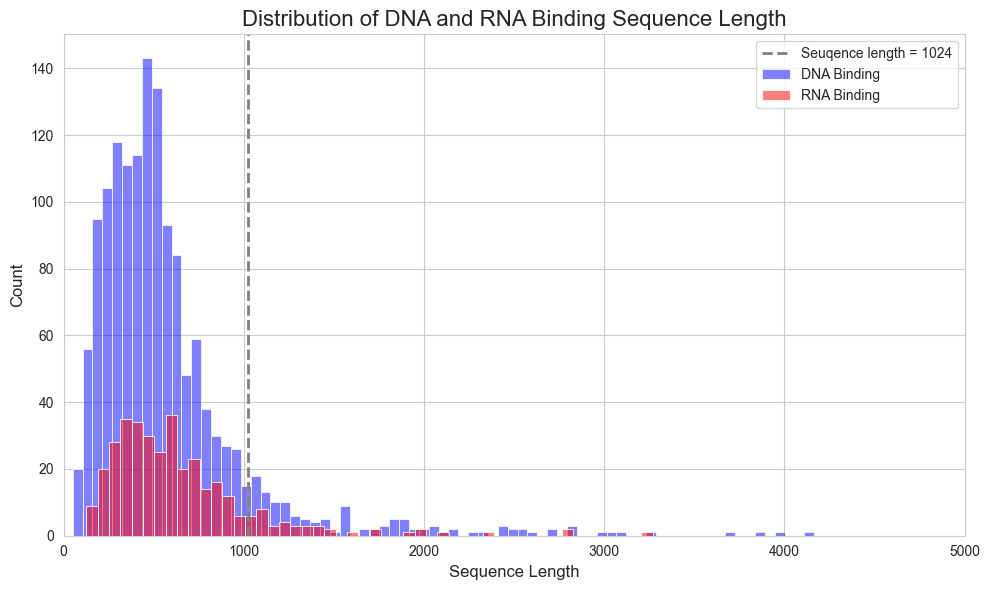

In [38]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 스타일 설정
sns.set_style('whitegrid')  # 'white', 'darkgrid', 'ticks' 등 다양한 스타일이 있음

# 그래프 그리기
plt.figure(figsize=(10, 6))  # 그래프 크기 설정 (가로 10, 세로 6)

# DNA sequence의 히스토그램
sns.histplot(
    data=DBP['sequence length'],
    color='blue',
    label='DNA Binding',
    alpha=0.5,
    bins=100  # 히스토그램 구간 수 조절
)

# RNA sequence의 히스토그램
sns.histplot(
    data=RBP['sequence length'],
    color='red',
    label='RNA Binding',
    alpha=0.5,
    bins=50
)
plt.axvline(x=1024, color='gray', linestyle='--', linewidth=2, label='Seuqence length = 1024')

# 그래프 제목 및 축 라벨 설정
plt.title('Distribution of DNA and RNA Binding Sequence Length', fontsize=16)
plt.xlabel('Sequence Length', fontsize=12)
plt.ylabel('Count', fontsize=12)

# 범례, x축 범위, 레이아웃 설정
plt.xlim(0, 5000)
plt.legend()
plt.tight_layout()

# 그래프 출력
plt.show()

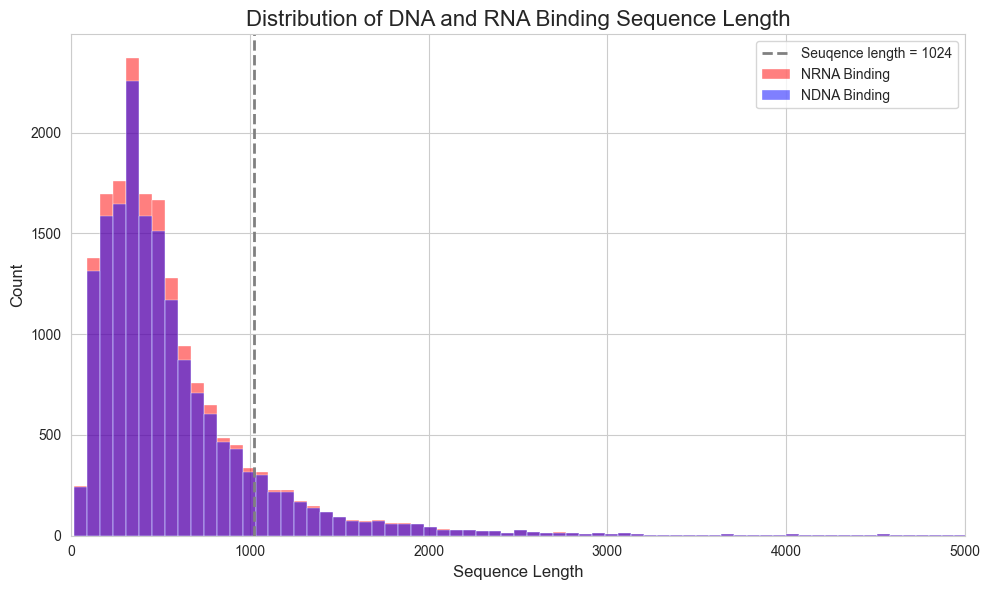

In [47]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 스타일 설정
sns.set_style('whitegrid')  # 'white', 'darkgrid', 'ticks' 등 다양한 스타일이 있음

# 그래프 그리기
plt.figure(figsize=(10, 6))  # 그래프 크기 설정 (가로 10, 세로 6)

# RNA sequence의 히스토그램
sns.histplot(
    data=NRBP['sequence length'],
    color='red',
    label='NRNA Binding',
    alpha=0.5,
    bins=200
)

# DNA sequence의 히스토그램
sns.histplot(
    data=NDBP['sequence length'],
    color='blue',
    label='NDNA Binding',
    alpha=0.5,
    bins=200  # 히스토그램 구간 수 조절
)

plt.axvline(x=1024, color='gray', linestyle='--', linewidth=2, label='Seuqence length = 1024')

# 그래프 제목 및 축 라벨 설정
plt.title('Distribution of DNA and RNA Binding Sequence Length', fontsize=16)
plt.xlabel('Sequence Length', fontsize=12)
plt.ylabel('Count', fontsize=12)

# 범례, x축 범위, 레이아웃 설정
plt.xlim(0, 5000)
plt.legend()
plt.tight_layout()

# 그래프 출력
plt.show()